# Further Research 2 -- State Affordability Convergence

## Background

Malaysia has a single national fee structure for public universities. A student
from Kelantan and a student from KL pay the same amount for the same degree.
On the surface this looks fair. But fair price does not mean equal burden.
When the fee is the same but the income is different, the sacrifice is not the same.

A family in KL earning roughly RM 10,000 a month spends about 1.4 months of their
full household income on a public degree. A family in Kelantan earning roughly
RM 3,600 a month spends about 3.9 months on the exact same degree. Same fee.
Same piece of paper at the end. Very different financial weight.

This is what the affordability index measures -- not the price of education,
but the sacrifice required to access it. And the sacrifice varies enormously
depending on where you were born.

**Why convergence?**

Household incomes have been growing across all states since 2012, and that growth
should in theory be pulling lower-income states closer to KL's level. The convergence
analysis tests whether that is actually happening, and if so, how long it will take.

The answer matters because there are two very different stories the data could tell.
The first is that the gap is closing steadily and lower-income states will reach
KL's affordability level within a generation -- uncomfortable but manageable.
The second is that the gap is closing so slowly that no amount of income growth
alone will fix it within any policy-relevant timeframe. If the second story is true,
then waiting for the economy to naturally equalise is not a strategy -- it is a
choice to maintain the current inequality indefinitely.

If the data says it will take 30 years for a state to reach KL's level, it means
a whole generation of students from that region is being told to wait three decades
for the same head start that a student in KL has today. The convergence year is
that wait time expressed as a single number.

**Why both pathways?**

The public pathway gap is real but it has a ceiling -- public fees are regulated
and relatively stable. The private pathway gap has no such ceiling. For families
who cannot access public universities, the convergence timeline is not measured
in decades. For many states it does not close at all within the projection window.

**Two parts:**

| Part | Fee basis | Question |
|---|---|---|
| A | Public (UTM, UM -- CPI-deflated) | When does each state reach KL's 2022 public affordability level? |
| B | Private (APU, Taylors -- CPI-deflated, upper bound) | When does each state reach the same benchmark on the private pathway? |


## Setup -- Libraries and Data

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from sklearn.linear_model import LinearRegression
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
RED    = '#DC2626'
GRAY   = '#6B7280'
PURPLE = '#7C3AED'
TEAL   = '#0D9488'

print("Libraries loaded.")


Libraries loaded.


In [58]:
hh_state = pd.read_csv('C:\\Users\\koksl\\vscfile\\EduNilai\\data\\cleaned\\hh_income_state.csv', parse_dates=['date'])
cpi_raw  = pd.read_csv('C:/Users/koksl/vscfile/EduNilai/data/cleaned/cpi.csv',                parse_dates=['date'])
fees_raw = pd.read_csv('C:/Users/koksl/vscfile/EduNilai/data/cleaned/fees_mean.csv')

hh_state['year'] = hh_state['date'].dt.year
cpi_raw['year']  = cpi_raw['date'].dt.year

print("Data loaded:")
print(f"  State household income: {len(hh_state)} rows")
print(f"  States: {sorted(hh_state['state'].unique())}")
print(f"  Years:  {sorted(hh_state['year'].unique())}")


Data loaded:
  State household income: 96 rows
  States: ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya']
  Years:  [2012, 2014, 2016, 2019, 2020, 2022]


In [59]:
fees_raw['public_avg']  = fees_raw[['UTM', 'UM']].mean(axis=1)
fees_raw['private_avg'] = fees_raw[["APU", "Taylor's"]].mean(axis=1)

PUBLIC_FEE_2024  = fees_raw['public_avg'].mean()
PRIVATE_FEE_2024 = fees_raw['private_avg'].mean()

edu_cpi  = cpi_raw[cpi_raw['division']=='10'].set_index('year')['index'].astype(float)
CPI_2024 = edu_cpi[2024]

print(f"2024 fee values (base for CPI deflation):")
print(f"  Public  fee (UTM + UM):           RM {PUBLIC_FEE_2024:>10,.0f}")
print(f"  Private fee (APU + Taylors):      RM {PRIVATE_FEE_2024:>10,.0f}  (upper bound)")
print(f"  Private-to-public ratio:          {PRIVATE_FEE_2024/PUBLIC_FEE_2024:.1f}x")
print()
print(f"Education CPI 2024: {CPI_2024:.4f}  (used as deflation base)")


2024 fee values (base for CPI deflation):
  Public  fee (UTM + UM):           RM     11,229
  Private fee (APU + Taylors):      RM    125,198  (upper bound)
  Private-to-public ratio:          11.1x

Education CPI 2024: 126.5917  (used as deflation base)


In [60]:
HIES_YEARS = [2012, 2014, 2016, 2019, 2020, 2022]

# Deflated fee for each HIES year
# estimated_fee_year_X = fee_2024 x (edu_cpi_X / edu_cpi_2024)
# Both income and fees move -- gives honest historical affordability
deflated_fees = {}
for yr in HIES_YEARS:
    deflated_fees[yr] = {
        'public':  PUBLIC_FEE_2024  * (edu_cpi[yr] / CPI_2024),
        'private': PRIVATE_FEE_2024 * (edu_cpi[yr] / CPI_2024),
    }

print("CPI-deflated fees by HIES year:")
print(f"{'Year':<8} {'Public fee':>12} {'Private fee':>14}")
print("-" * 38)
for yr in HIES_YEARS:
    print(f"  {yr:<6} RM {deflated_fees[yr]['public']:>8,.0f}  RM {deflated_fees[yr]['private']:>9,.0f}")
print()
print("Fees in 2012 were roughly 17% lower than today in real terms.")
print("Using deflated fees means both income and fees move in the calculation.")


CPI-deflated fees by HIES year:
Year       Public fee    Private fee
--------------------------------------
  2012   RM    9,285  RM   103,531
  2014   RM    9,735  RM   108,541
  2016   RM   10,185  RM   113,561
  2019   RM   10,617  RM   118,374
  2020   RM   10,724  RM   119,569
  2022   RM   10,857  RM   121,052

Fees in 2012 were roughly 17% lower than today in real terms.
Using deflated fees means both income and fees move in the calculation.


---
# Part A -- Public University Pathway

The public pathway analysis answers the core question: how long before a family
from a low-income state reaches the same affordability level as a family in KL today?

KL's 2022 public affordability level is the target. Every state is judged against
this single benchmark. The convergence year is the year each state's projected
affordability index crosses below KL's 2022 level -- the point at which a family
from that state sacrifices no more than a KL family does today.


---
## Step A1 -- Affordability Heatmap: All States x All HIES Years

Before we ask how long convergence takes, we first need to see where every state
actually stands and how that has changed over time. We compute the affordability
index for every state for each of the six HIES years using CPI-deflated fees.

The result is a heatmap with states on one axis and years on the other. Each cell
shows the affordability index for that state in that year -- how many years of full
household income a degree would cost. States are sorted from most burdened to least
burdened in 2022. Green cells mean the burden is close to KL's level. Red cells
mean the family is far behind.

This single chart tells the full geographic story before any projection begins.


### A1a -- Compute the affordability index for every state and every HIES year

For each state and each year, we divide the CPI-deflated fee by that year's annual household income. This gives us the affordability index -- how many years of full income a degree costs.

In [61]:
aff_rows = []
for _, row in hh_state.iterrows():
    yr             = row['year']
    if yr not in deflated_fees:
        continue
    annual_income  = row['income_median'] * 12
    aff_rows.append({
        'state':        row['state'],
        'year':         yr,
        'income_median':row['income_median'],
        'aff_public':   deflated_fees[yr]['public']  / annual_income,
        'aff_private':  deflated_fees[yr]['private'] / annual_income,
    })

aff_df = pd.DataFrame(aff_rows)

print(f"Affordability index computed: {len(aff_df)} state-year observations")
print(f"States: {aff_df['state'].nunique()}  |  Years: {sorted(aff_df['year'].unique())}")
print()
print("Sample -- 2022 values (sorted by public affordability, highest burden first):")
sample_2022 = aff_df[aff_df['year']==2022].sort_values('aff_public', ascending=False)
print(f"{'State':<25} {'Income/mth':>12} {'Public idx':>12} {'Private idx':>13}")
print("-" * 65)
for _, r in sample_2022.iterrows():
    print(f"  {r['state']:<23} RM {r['income_median']:>6,}    {r['aff_public']:>10.4f}   {r['aff_private']:>11.4f}")


Affordability index computed: 96 state-year observations
States: 16  |  Years: [2012, 2014, 2016, 2019, 2020, 2022]

Sample -- 2022 values (sorted by public affordability, highest burden first):
State                       Income/mth   Public idx   Private idx
-----------------------------------------------------------------
  Kelantan                RM  3,614        0.2503        2.7913
  Kedah                   RM  4,402        0.2055        2.2916
  Perak                   RM  4,494        0.2013        2.2447
  Sabah                   RM  4,577        0.1977        2.2040
  Perlis                  RM  4,713        0.1920        2.1404
  Pahang                  RM  4,753        0.1904        2.1224
  Sarawak                 RM  4,978        0.1817        2.0265
  Negeri Sembilan         RM  5,226        0.1731        1.9303
  Terengganu              RM  5,878        0.1539        1.7162
  Melaka                  RM  6,210        0.1457        1.6244
  Pulau Pinang            RM  6,5

### A1b -- Store KL's 2022 level as the convergence target

KL's 2022 public affordability level is the benchmark every state is working towards. We store it now and use it throughout the rest of the analysis.

In [62]:
KL_PUBLIC_2022 = aff_df[
    (aff_df['state']=='W.P. Kuala Lumpur') & (aff_df['year']==2022)
]['aff_public'].values[0]

print(f"KL 2022 public affordability level: {KL_PUBLIC_2022:.4f}")
print()
print(f"In plain terms: a KL family spends {KL_PUBLIC_2022*12:.1f} months of full")
print(f"household income on a public degree in 2022.")
print()
print("Every state is judged against this single number.")
print("The convergence year is when a state's index drops below it.")


KL 2022 public affordability level: 0.0884

In plain terms: a KL family spends 1.1 months of full
household income on a public degree in 2022.

Every state is judged against this single number.
The convergence year is when a state's index drops below it.


### A1c -- Reshape into a pivot table for the heatmap

We pivot the data so states are rows and years are columns. This format is what the heatmap function expects.

In [63]:
pivot_public = aff_df.pivot(index='state', columns='year', values='aff_public')
pivot_public = pivot_public.sort_values(2022, ascending=False)

print("Pivot table (public affordability index):")
print(f"{'State':<25}", end='')
for yr in HIES_YEARS:
    print(f"  {yr}", end='')
print()
print("-" * 75)
for state, row in pivot_public.iterrows():
    print(f"  {state:<23}", end='')
    for yr in HIES_YEARS:
        val = row[yr] if yr in row.index and not pd.isna(row[yr]) else 0
        print(f"  {val:.3f}", end='')
    print()


Pivot table (public affordability index):
State                      2012  2014  2016  2019  2020  2022
---------------------------------------------------------------------------
  Kelantan                 0.340  0.299  0.276  0.248  0.297  0.250
  Kedah                    0.294  0.235  0.223  0.205  0.233  0.206
  Perak                    0.290  0.235  0.212  0.207  0.238  0.201
  Sabah                    0.271  0.217  0.207  0.209  0.237  0.198
  Perlis                   0.324  0.232  0.202  0.193  0.221  0.192
  Pahang                   0.252  0.239  0.213  0.199  0.222  0.190
  Sarawak                  0.254  0.215  0.204  0.195  0.233  0.182
  Negeri Sembilan          0.216  0.197  0.185  0.177  0.200  0.173
  Terengganu               0.255  0.215  0.181  0.160  0.187  0.154
  Melaka                   0.197  0.161  0.152  0.146  0.164  0.146
  Pulau Pinang             0.192  0.173  0.157  0.143  0.163  0.139
  Johor                    0.212  0.156  0.150  0.138  0.157  0.132
  W.

### A1d -- Plot the heatmap

Each cell is coloured on a green-to-red scale. Green means the burden is close to KL's 2022 level. Red means the state is far behind. The number inside each cell is the affordability index for that state and year.

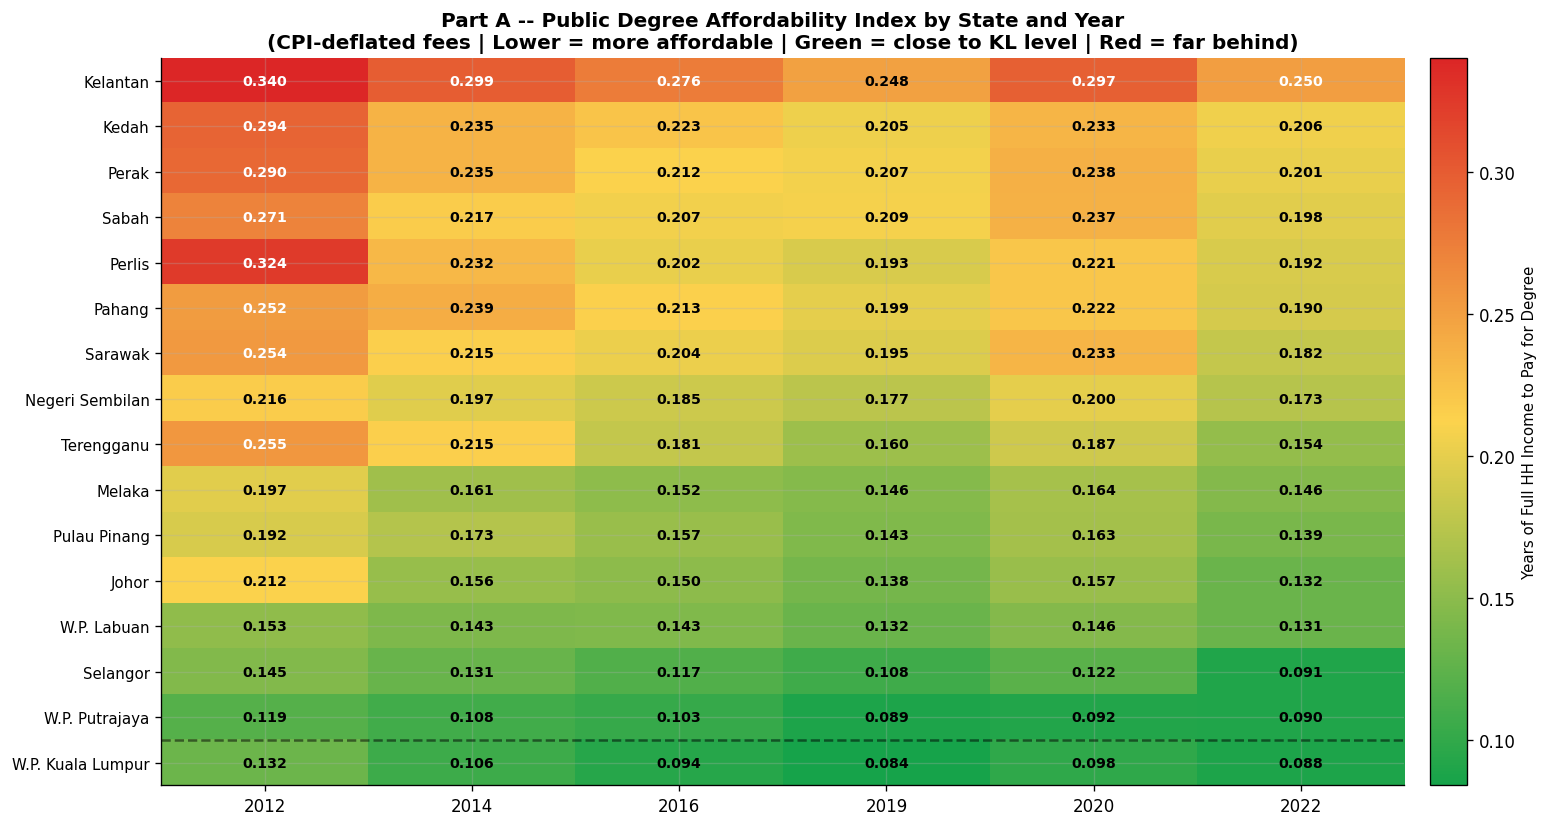

In [64]:
fig, ax = plt.subplots(figsize=(13, 7))
cmap_heat = LinearSegmentedColormap.from_list('afford', ['#16A34A','#FCD34D','#DC2626'])
im = ax.imshow(pivot_public.values, aspect='auto', cmap=cmap_heat)

ax.set_xticks(range(len(pivot_public.columns)))
ax.set_xticklabels(pivot_public.columns, fontsize=10)
ax.set_yticks(range(len(pivot_public.index)))
ax.set_yticklabels(pivot_public.index, fontsize=9)

for i in range(len(pivot_public.index)):
    for j in range(len(pivot_public.columns)):
        val = pivot_public.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=8.5, fontweight='bold',
                    color='white' if val > 0.25 else 'black')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Years of Full HH Income to Pay for Degree', fontsize=9)
ax.axhline(list(pivot_public.index).index('W.P. Kuala Lumpur') - 0.5,
           color='black', lw=1.5, ls='--', alpha=0.5)
ax.set_title('Part A -- Public Degree Affordability Index by State and Year\n'
             '(CPI-deflated fees | Lower = more affordable | '
             'Green = close to KL level | Red = far behind)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


---
## Step A2 -- How Fast Is Each State Improving?

The heatmap shows where each state is. This step shows how fast each state is moving.
We fit a linear regression on each state's affordability index across the six HIES
years. The slope of that regression line tells us how many index points the state
improves per year on average.

A steeper negative slope means the state is closing the gap faster. A flat or
positive slope means the state is barely improving or getting worse. This chart
makes it immediately clear which states are on track and which are not.


### A2a -- Fit a linear regression for each state

For each state we use the six HIES years as the x-axis and the affordability index as the y-axis. The slope of the fitted line is the annual improvement rate. A negative slope means the index is falling -- improving.

In [65]:
pub_trends = {}
for state in aff_df['state'].unique():
    df_s  = aff_df[aff_df['state']==state].sort_values('year')
    X     = df_s['year'].values.reshape(-1, 1)
    y_arr = df_s['aff_public'].values
    model = LinearRegression().fit(X, y_arr)
    pub_trends[state] = {
        'slope':     model.coef_[0],
        'intercept': model.intercept_,
        'model':     model,
        'data':      df_s,
    }

print("Linear regression fitted for each state.")
print()
print("Slope values (negative = improving):")
print(f"{'State':<25} {'Slope':>10} {'Improvement pp/yr':>20}")
print("-" * 58)
for state, t in sorted(pub_trends.items(), key=lambda x: x[1]['slope']):
    print(f"  {state:<23} {t['slope']:>10.5f}  {-t['slope']*100:>18.3f} pp/yr")


Linear regression fitted for each state.

Slope values (negative = improving):
State                          Slope    Improvement pp/yr
----------------------------------------------------------
  Perlis                    -0.01012               1.012 pp/yr
  Terengganu                -0.00884               0.884 pp/yr
  Kelantan                  -0.00711               0.711 pp/yr
  Kedah                     -0.00677               0.677 pp/yr
  Perak                     -0.00639               0.639 pp/yr
  Johor                     -0.00593               0.593 pp/yr
  Pahang                    -0.00545               0.545 pp/yr
  Sarawak                   -0.00458               0.458 pp/yr
  Pulau Pinang              -0.00441               0.441 pp/yr
  Sabah                     -0.00433               0.433 pp/yr
  Selangor                  -0.00432               0.432 pp/yr
  W.P. Kuala Lumpur         -0.00371               0.371 pp/yr
  Melaka                    -0.00371            

### A2b -- Convert slope to improvement rate for the chart

The slope is negative for improving states. We multiply by -1 so positive values mean improving. We multiply by 100 to express in percentage points per year rather than raw index units.

In [66]:
slope_df = pd.DataFrame([
    {'state': s, 'improvement_pp_yr': -t['slope'] * 100}
    for s, t in pub_trends.items()
]).sort_values('improvement_pp_yr', ascending=True)

print("Annual improvement rate per state (positive = improving):")
print(f"{'State':<25} {'Improvement pp/yr':>20}")
print("-" * 48)
for _, row in slope_df.iterrows():
    flag = '<-- WORSENING' if row['improvement_pp_yr'] < 0 else ''
    print(f"  {row['state']:<23} {row['improvement_pp_yr']:>18.3f}  {flag}")


Annual improvement rate per state (positive = improving):
State                        Improvement pp/yr
------------------------------------------------
  W.P. Labuan                          0.166  
  W.P. Putrajaya                       0.303  
  Negeri Sembilan                      0.317  
  Melaka                               0.371  
  W.P. Kuala Lumpur                    0.371  
  Selangor                             0.432  
  Sabah                                0.433  
  Pulau Pinang                         0.441  
  Sarawak                              0.458  
  Pahang                               0.545  
  Johor                                0.593  
  Perak                                0.639  
  Kedah                                0.677  
  Kelantan                             0.711  
  Terengganu                           0.884  
  Perlis                               1.012  


### A2c -- Plot the improvement rate bar chart

Each bar represents one state. A bar pointing to the right means the state is improving -- its affordability index is falling year on year. A longer bar means faster improvement. A bar pointing to the left means the state's affordability is actually getting worse over time, which would make convergence impossible under current trends.

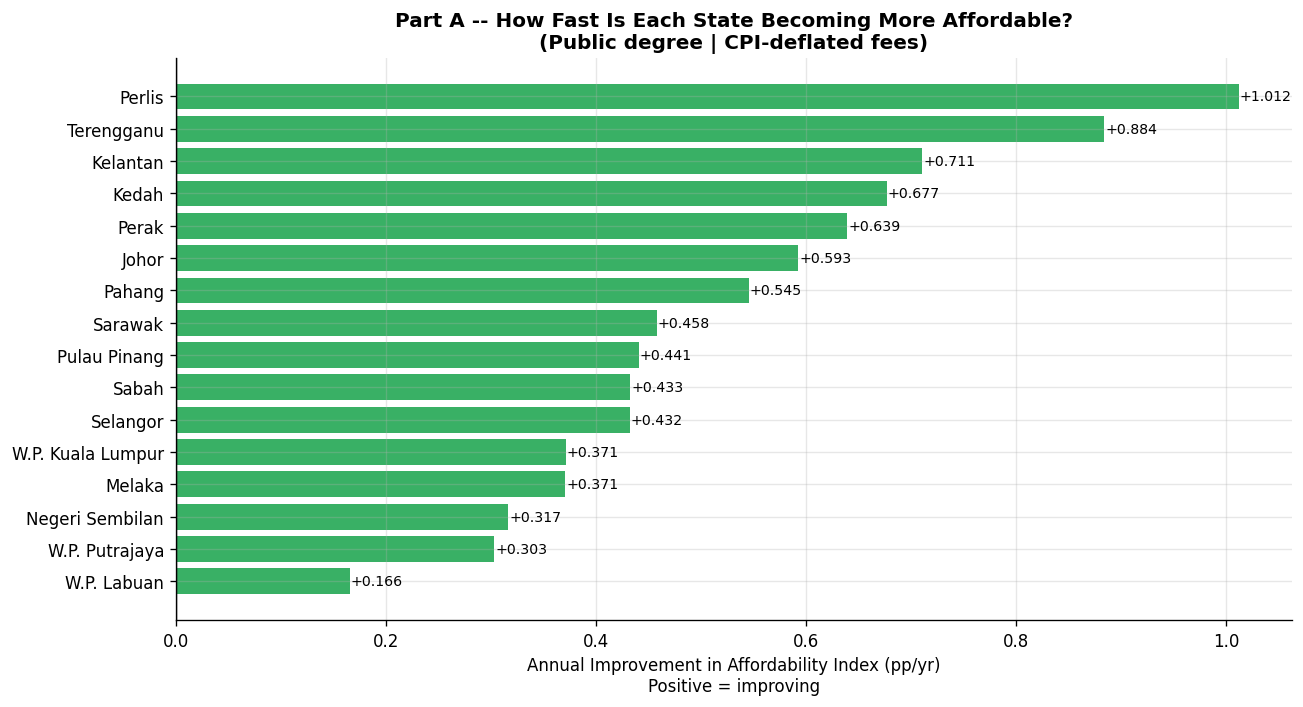

In [67]:
fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = [GREEN if v > 0 else RED for v in slope_df['improvement_pp_yr']]
bars = ax.barh(slope_df['state'], slope_df['improvement_pp_yr'],
               color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Annual Improvement in Affordability Index (pp/yr)\nPositive = improving')
ax.set_title('Part A -- How Fast Is Each State Becoming More Affordable?\n'
             '(Public degree | CPI-deflated fees)', fontweight='bold')
for bar, val in zip(bars, slope_df['improvement_pp_yr']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8.5)
plt.tight_layout()
plt.show()


### A2d -- Print the states that are improving slowest

The states with the smallest improvement rate are the ones at greatest risk of never converging within a policy-relevant timeframe. We flag them explicitly.

In [68]:
national_avg_improvement = slope_df['improvement_pp_yr'].mean()
print(f"National average improvement rate: {national_avg_improvement:.3f} pp/yr")
print()
print("States improving below the national average:")
below_avg = slope_df[slope_df['improvement_pp_yr'] < national_avg_improvement]
for _, row in below_avg.sort_values('improvement_pp_yr').iterrows():
    print(f"  {row['state']:<25} {row['improvement_pp_yr']:>+.3f} pp/yr")
print()
print("These states will take the longest to converge -- or may never converge")
print("within the projection window if their improvement rate does not accelerate.")


National average improvement rate: 0.522 pp/yr

States improving below the national average:
  W.P. Labuan               +0.166 pp/yr
  W.P. Putrajaya            +0.303 pp/yr
  Negeri Sembilan           +0.317 pp/yr
  Melaka                    +0.371 pp/yr
  W.P. Kuala Lumpur         +0.371 pp/yr
  Selangor                  +0.432 pp/yr
  Sabah                     +0.433 pp/yr
  Pulau Pinang              +0.441 pp/yr
  Sarawak                   +0.458 pp/yr

These states will take the longest to converge -- or may never converge
within the projection window if their improvement rate does not accelerate.


---
## Step A3 -- When Does Each State Reach KL's Current Level?

This is the core question of Part A. We take each state's regression line and
project it forward year by year until it crosses KL's 2022 affordability level.
The year it crosses is the convergence year -- the direct answer to how long
before that state catches up to where KL is today.

We show this as two charts side by side. The left chart shows the projection lines
for the five most burdened states and the two states closest to KL, with the
crossing year annotated. The right chart shows the gap between each state and
KL's 2022 level as a horizontal bar with the convergence year labelled at the end
so both the size of the gap and the time needed to close it are visible at once.


### A3a -- Project each state's regression line forward and find the crossing year

For each state we extend the regression line from 2022 to 2070. We scan forward year by year and record the first year the projected index falls below KL's 2022 level. If it never crosses before 2070, we record None.

In [69]:
PROJ_YEARS = np.arange(2022, 2071)

pub_conv = []
for state, t in pub_trends.items():
    if state == 'W.P. Kuala Lumpur':
        continue
    proj    = t['model'].predict(PROJ_YEARS.reshape(-1, 1))
    crossed = PROJ_YEARS[proj <= KL_PUBLIC_2022]
    conv_yr = int(crossed[0]) if len(crossed) > 0 else None
    aff_2022 = aff_df[(aff_df['state']==state) & (aff_df['year']==2022)]['aff_public'].values[0]
    pub_conv.append({
        'state':     state,
        'aff_2022':  aff_2022,
        'gap':       aff_2022 - KL_PUBLIC_2022,
        'conv_year': conv_yr,
    })

pub_conv_df = pd.DataFrame(pub_conv).sort_values('aff_2022', ascending=False)

print("Public pathway convergence years:")
print(f"{'State':<25} {'2022 Index':>12} {'Gap to KL':>12} {'Converges':>12}")
print("-" * 65)
for _, row in pub_conv_df.iterrows():
    cy = str(int(row['conv_year'])) if row['conv_year'] else '>2070'
    wait = str(int(row['conv_year']) - 2022) + ' yrs' if row['conv_year'] else '>48 yrs'
    print(f"  {row['state']:<23} {row['aff_2022']:>12.4f} {row['gap']:>12.4f} {cy:>8}  ({wait})")


Public pathway convergence years:
State                       2022 Index    Gap to KL    Converges
-----------------------------------------------------------------
  Kelantan                      0.2503       0.1619     2045  (23 yrs)
  Kedah                         0.2055       0.1171     2039  (17 yrs)
  Perak                         0.2013       0.1129     2040  (18 yrs)
  Sabah                         0.1977       0.1093     2049  (27 yrs)
  Perlis                        0.1920       0.1036     2031  (9 yrs)
  Pahang                        0.1904       0.1019     2042  (20 yrs)
  Sarawak                       0.1817       0.0933     2045  (23 yrs)
  Negeri Sembilan               0.1731       0.0847     2050  (28 yrs)
  Terengganu                    0.1539       0.0655     2029  (7 yrs)
  Melaka                        0.1457       0.0573     2037  (15 yrs)
  Pulau Pinang                  0.1391       0.0507     2034  (12 yrs)
  Johor                         0.1315       0.0431     

### A3b -- Select focus states for the projection chart

We auto-select the five most burdened states and the two states closest to KL. This gives the chart a complete range -- the worst cases and the best cases -- without overcrowding the panel.

In [70]:
worst_5 = pub_conv_df.nlargest(5, 'aff_2022')['state'].tolist()
best_2  = pub_conv_df.nsmallest(2, 'aff_2022')['state'].tolist()
focus   = ['W.P. Kuala Lumpur'] + best_2 + worst_5
palette = ['black', TEAL, BLUE, RED, ORANGE, PURPLE, '#B45309', '#0891B2']

print("Focus states selected for projection chart:")
print(f"  KL (benchmark):  W.P. Kuala Lumpur")
print(f"  Closest to KL:   {best_2}")
print(f"  Most burdened:   {worst_5}")


Focus states selected for projection chart:
  KL (benchmark):  W.P. Kuala Lumpur
  Closest to KL:   ['W.P. Putrajaya', 'Selangor']
  Most burdened:   ['Kelantan', 'Kedah', 'Perak', 'Sabah', 'Perlis']


### A3c -- Plot the convergence projection lines and gap bar chart

Two charts side by side. The left chart shows the historical index from 2012 to 2022 as solid lines, then the projected regression line as a dashed line for each focus state. The black dotted horizontal line is KL's 2022 level -- the target. Where a dashed line crosses it, the convergence year is annotated directly on the chart.

The right chart shows each state as a horizontal bar sized by how far above the KL benchmark it sits in 2022. The convergence year is labelled at the end of each bar so you can read both the size of the gap and the time needed to close it at once.

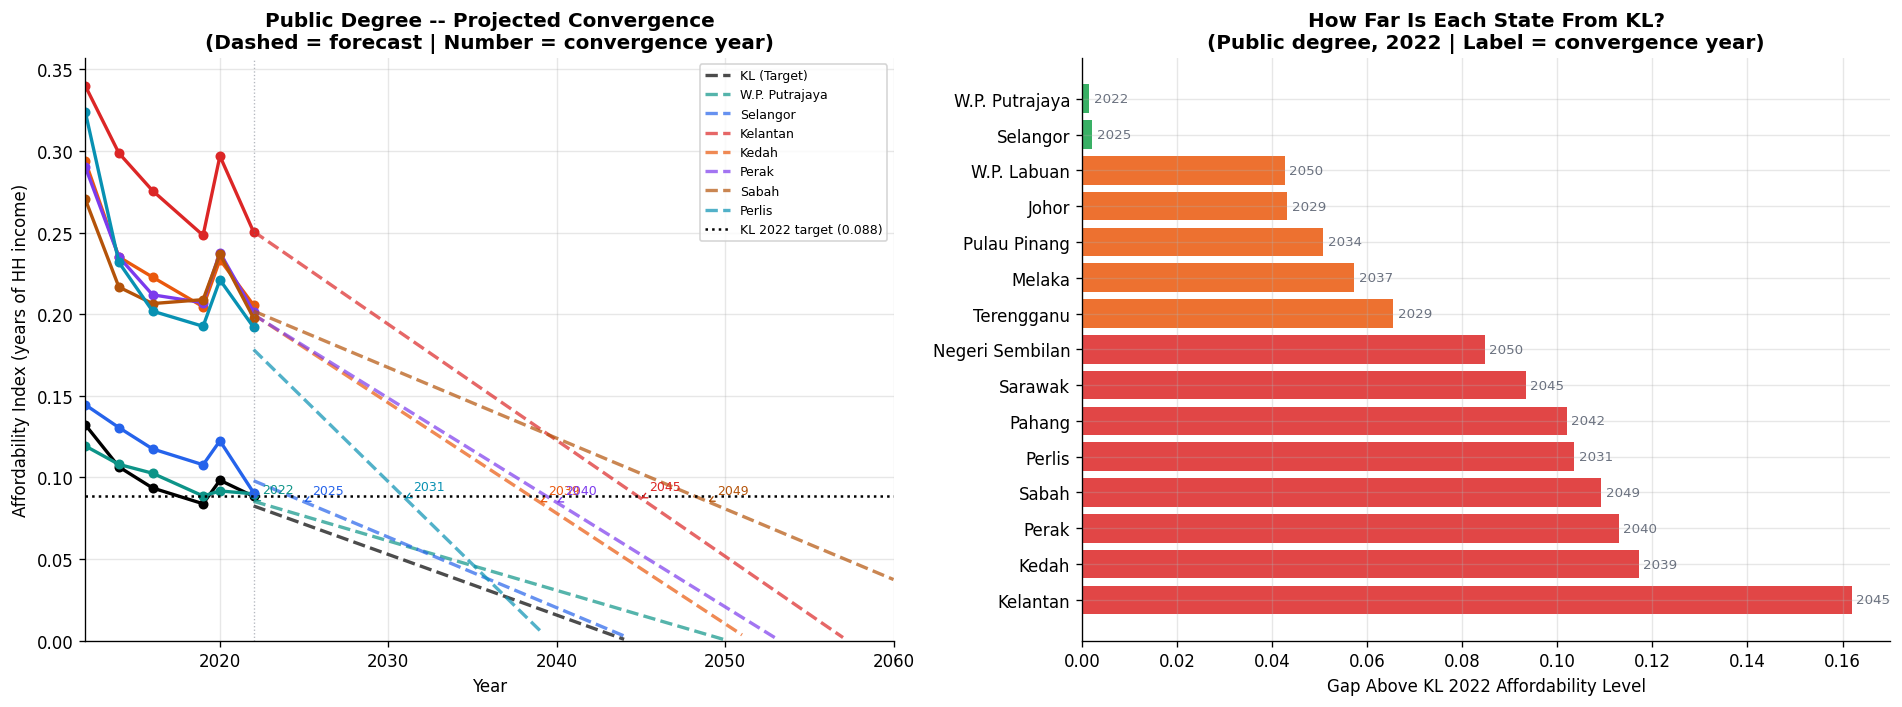

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, state in enumerate(focus):
    t        = pub_trends[state]
    hist     = aff_df[aff_df['state']==state].sort_values('year')
    proj     = t['model'].predict(PROJ_YEARS.reshape(-1, 1))
    proj_c   = np.maximum(proj, 0)
    color    = palette[i % len(palette)]
    lbl      = 'KL (Target)' if state == 'W.P. Kuala Lumpur' else state
    mask     = (PROJ_YEARS <= 2060) & (proj >= 0)

    axes[0].plot(hist['year'], hist['aff_public'],
                 color=color, lw=2, ls='-', marker='o', markersize=5)
    axes[0].plot(PROJ_YEARS[mask], proj_c[mask],
                 color=color, lw=2, ls='--', alpha=0.7, label=lbl)

    row = pub_conv_df[pub_conv_df['state']==state]
    if not row.empty and row['conv_year'].values[0]:
        cy = row['conv_year'].values[0]
        if cy <= 2060:
            cv = max(t['model'].predict([[cy]])[0], 0)
            axes[0].annotate(f'{cy}', xy=(cy, cv), xytext=(cy+0.5, cv+0.005),
                fontsize=7.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

axes[0].axhline(KL_PUBLIC_2022, color='black', lw=1.5, ls=':',
                label=f'KL 2022 target ({KL_PUBLIC_2022:.3f})')
axes[0].axvline(2022, color=GRAY, lw=0.8, ls=':', alpha=0.5)
axes[0].set_ylim(bottom=0)
axes[0].set_xlim(2012, 2060)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Affordability Index (years of HH income)')
axes[0].set_title('Public Degree -- Projected Convergence\n'
                  '(Dashed = forecast | Number = convergence year)',
                  fontweight='bold')
axes[0].legend(fontsize=7.5)

gap_sorted = pub_conv_df.sort_values('gap', ascending=False)
gap_colors = [RED if v > 0.08 else ORANGE if v > 0.04 else GREEN for v in gap_sorted['gap']]
bars = axes[1].barh(gap_sorted['state'], gap_sorted['gap'],
                    color=gap_colors, alpha=0.85)
axes[1].set_xlabel('Gap Above KL 2022 Affordability Level')
axes[1].set_title('How Far Is Each State From KL?\n'
                  '(Public degree, 2022 | Label = convergence year)',
                  fontweight='bold')
for bar, (_, row) in zip(bars, gap_sorted.iterrows()):
    lbl = str(int(row['conv_year'])) if row['conv_year'] else '>2070'
    axes[1].text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                 lbl, va='center', fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()


### A3d -- Summarise the convergence findings in plain language

Rather than leaving the convergence years as a table of numbers, we translate them into plain statements. A state converging in 2045 means a student enrolling today will graduate, work for over two decades, and still not have seen their home state reach the affordability level that KL has right now.

In [72]:
print("CONVERGENCE SUMMARY -- PUBLIC PATHWAY")
print("=" * 55)
print(f"Target: KL 2022 public affordability = {KL_PUBLIC_2022:.4f}")
print(f"  (A KL family spends {KL_PUBLIC_2022*12:.1f} months of full income on a public degree)")
print()
within_10  = pub_conv_df[pub_conv_df['conv_year'].apply(lambda x: x is not None and x <= 2032)]
within_20  = pub_conv_df[pub_conv_df['conv_year'].apply(lambda x: x is not None and x <= 2042)]
never      = pub_conv_df[pub_conv_df['conv_year'].isna()]

print(f"States converging within 10 years (by 2032): {len(within_10)}")
for _, r in within_10.iterrows():
    print(f"  {r['state']} -- {int(r['conv_year'])}")
print()
print(f"States converging within 20 years (by 2042): {len(within_20)}")
print()
print(f"States NOT converging before 2070: {len(never)}")
for _, r in never.iterrows():
    print(f"  {r['state']}")
print()
print("For states that do not converge before 2070:")
print("A student enrolling today will graduate, work their entire career,")
print("and retire before their home state reaches KL's current level.")


CONVERGENCE SUMMARY -- PUBLIC PATHWAY
Target: KL 2022 public affordability = 0.0884
  (A KL family spends 1.1 months of full income on a public degree)

States converging within 10 years (by 2032): 5
  Perlis -- 2031
  Terengganu -- 2029
  Johor -- 2029
  Selangor -- 2025
  W.P. Putrajaya -- 2022

States converging within 20 years (by 2042): 10

States NOT converging before 2070: 0

For states that do not converge before 2070:
A student enrolling today will graduate, work their entire career,
and retire before their home state reaches KL's current level.


---
## Step A4 -- What If Fees Keep Rising?

The convergence years in Step A3 assume fees stay flat going forward at their
2022 deflated level. This is the optimistic case. In reality, education costs
have been rising at roughly 1.6% per year based on the historical education CPI.

We run a sensitivity test that asks: what happens to each state's convergence year
if fees keep rising at their historical CPI rate instead of staying flat?

For each state we rerun the projection with growing fees and find the new
convergence year. We show the two sets of convergence years side by side as
grouped bars -- flat fees versus rising fees -- so the delay caused by fee
growth is immediately visible for every state.


### A4a -- Compute the education CPI growth rate for the sensitivity test

We use the same annualised CAGR formula used in Research 3 to compute the historical education CPI growth rate from 2012 to 2022.

In [73]:
cpi_2012 = edu_cpi[2012]
cpi_2022 = edu_cpi[2022]
EDU_CPI_GROWTH_RATE = (cpi_2022 / cpi_2012) ** (1/10) - 1

print(f"Education CPI 2012: {cpi_2012:.4f}")
print(f"Education CPI 2022: {cpi_2022:.4f}")
print(f"Annualised CPI growth rate (2012-2022): {EDU_CPI_GROWTH_RATE*100:.2f}%/yr")
print()
print("This is the rate used in the sensitivity test.")
print("If fees grow at this rate going forward, convergence takes longer.")


Education CPI 2012: 104.6833
Education CPI 2022: 122.4000
Annualised CPI growth rate (2012-2022): 1.58%/yr

This is the rate used in the sensitivity test.
If fees grow at this rate going forward, convergence takes longer.


### A4b -- Project convergence with rising fees for each state

For the rising-fee scenario, we back-calculate the implied household income from the projected affordability index, then apply the growing fee to get a new affordability index. We find the first year the new index drops below KL's 2022 level.

In [74]:
pub_fee_2022 = deflated_fees[2022]['public']
sensitivity_results = []

for state, t in pub_trends.items():
    if state == 'W.P. Kuala Lumpur':
        continue
    projected_affordability = t['model'].predict(PROJ_YEARS.reshape(-1, 1))

    # Back-calculate implied monthly income from projected affordability index
    # Since: aff = fee / (income x 12)  =>  income = fee / (aff x 12)
    with np.errstate(divide='ignore', invalid='ignore'):
        projected_monthly_income = np.where(
            projected_affordability > 0,
            pub_fee_2022 / (projected_affordability * 12),
            np.nan
        )

    # Apply rising fee
    years_since_2022   = PROJ_YEARS - 2022
    fee_rising         = pub_fee_2022 * (1 + EDU_CPI_GROWTH_RATE) ** years_since_2022

    # Recompute affordability with rising fee
    with np.errstate(divide='ignore', invalid='ignore'):
        aff_rising = np.where(
            projected_monthly_income > 0,
            fee_rising / (projected_monthly_income * 12),
            np.nan
        )

    crossed_rising = PROJ_YEARS[(aff_rising <= KL_PUBLIC_2022) & ~np.isnan(aff_rising)]
    conv_rising    = int(crossed_rising[0]) if len(crossed_rising) > 0 else None
    conv_flat      = pub_conv_df[pub_conv_df['state']==state]['conv_year'].values[0]

    sensitivity_results.append({
        'state':              state,
        'convergence_flat':   conv_flat,
        'convergence_rising': conv_rising,
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df['flat_plot']   = sensitivity_df['convergence_flat'].apply(lambda x: int(x) if pd.notna(x) and x else 9999)
sensitivity_df['rising_plot'] = sensitivity_df['convergence_rising'].apply(lambda x: int(x) if pd.notna(x) and x else 9999)
sensitivity_sorted = sensitivity_df.sort_values('flat_plot')

print("Sensitivity results -- flat fees vs rising fees:")
print(f"{'State':<25} {'Flat fees':>12} {'Rising fees':>13} {'Delay':>8}")
print("-" * 62)
for _, row in sensitivity_sorted.iterrows():
    flat_str   = str(int(row['convergence_flat']))   if pd.notna(row['convergence_flat'])   and row['convergence_flat']   else '>2070'
    rising_str = str(int(row['convergence_rising'])) if pd.notna(row['convergence_rising']) and row['convergence_rising'] else '>2070'
    if pd.notna(row['convergence_flat']) and pd.notna(row['convergence_rising']) and row['convergence_flat'] and row['convergence_rising']:
        delay = f"+{int(row['convergence_rising']) - int(row['convergence_flat'])} yrs"
    else:
        delay = 'n/a'
    print(f"  {row['state']:<23} {flat_str:>12} {rising_str:>13} {delay:>8}")

Sensitivity results -- flat fees vs rising fees:
State                        Flat fees   Rising fees    Delay
--------------------------------------------------------------
  W.P. Putrajaya                  2022          2022   +0 yrs
  Selangor                        2025          2026   +1 yrs
  Johor                           2029          2031   +2 yrs
  Terengganu                      2029          2031   +2 yrs
  Perlis                          2031          2033   +2 yrs
  Pulau Pinang                    2034          2039   +5 yrs
  Melaka                          2037          2044   +7 yrs
  Kedah                           2039          2042   +3 yrs
  Perak                           2040          2044   +4 yrs
  Pahang                          2042          2047   +5 yrs
  Kelantan                        2045          2050   +5 yrs
  Sarawak                         2045          2052   +7 yrs
  Sabah                           2049          2057   +8 yrs
  Negeri Sembilan   

### A4c -- Plot flat fees vs rising fees side by side

Each state has two bars -- one for flat fees and one for rising fees. The gap between the two bars is the delay caused by fee growth. A state where both bars end before 2070 converges under both scenarios but takes longer when fees rise. A state where the rising-fee bar hits the 2075 boundary means rising fees push convergence beyond 2070 entirely.

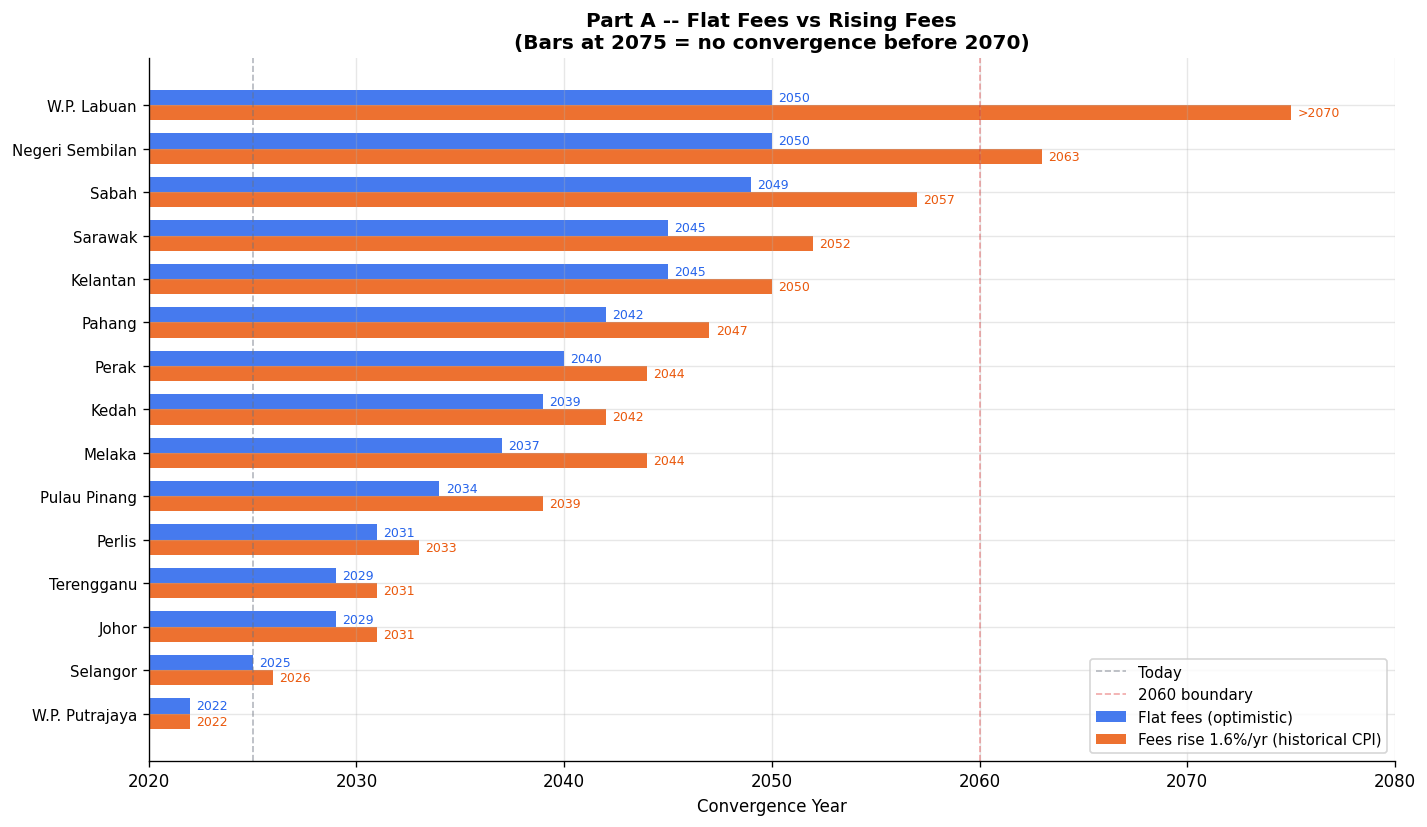

In [75]:
fig, ax = plt.subplots(figsize=(12, 7))
y     = np.arange(len(sensitivity_sorted))
h     = 0.35
flat_vals   = sensitivity_sorted['flat_plot'].values.astype(float)
rising_vals = sensitivity_sorted['rising_plot'].values.astype(float)
flat_vals[flat_vals     == 9999] = 2075
rising_vals[rising_vals == 9999] = 2075

ax.barh(y + h/2, flat_vals,   h, color=BLUE,   alpha=0.85,
        label='Flat fees (optimistic)')
ax.barh(y - h/2, rising_vals, h, color=ORANGE, alpha=0.85,
        label=f'Fees rise {EDU_CPI_GROWTH_RATE*100:.1f}%/yr (historical CPI)')
ax.set_yticks(y)
ax.set_yticklabels(sensitivity_sorted['state'], fontsize=9)
ax.axvline(2025, color=GRAY, lw=1, ls='--', alpha=0.5, label='Today')
ax.axvline(2060, color=RED,  lw=1, ls='--', alpha=0.4, label='2060 boundary')
ax.set_xlabel('Convergence Year')
ax.set_title('Part A -- Flat Fees vs Rising Fees\n'
             '(Bars at 2075 = no convergence before 2070)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(2020, 2080)
for bar in ax.patches[:len(y)]:
    lbl = str(int(bar.get_width())) if bar.get_width() < 2075 else '>2070'
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            lbl, va='center', fontsize=7.5, color=BLUE)
for bar in ax.patches[len(y):]:
    lbl = str(int(bar.get_width())) if bar.get_width() < 2075 else '>2070'
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            lbl, va='center', fontsize=7.5, color=ORANGE)
plt.tight_layout()
plt.show()


### A4d -- Summarise the sensitivity finding

We calculate the average and maximum delay caused by rising fees across all states that converge under both scenarios. We also flag any state that would have converged under flat fees but gets pushed beyond 2070 once fees are allowed to grow. These states are the most policy-sensitive -- a relatively small change in fee growth rate is the difference between convergence and no convergence.

In [76]:
delays = []
for _, row in sensitivity_df.iterrows():
    if pd.notna(row['convergence_flat']) and pd.notna(row['convergence_rising']) and row['convergence_flat'] and row['convergence_rising']:
        delays.append(int(row['convergence_rising']) - int(row['convergence_flat']))

if delays:
    print(f"Among states that converge under both scenarios:")
    print(f"  Average delay caused by rising fees: {np.mean(delays):.0f} years")
    print(f"  Maximum delay:                       {max(delays)} years")
    print()
print("States where rising fees push convergence beyond 2070:")
for _, row in sensitivity_df.iterrows():
    if not row['convergence_rising'] and row['convergence_flat']:
        print(f"  {row['state']} -- would have converged by {int(row['convergence_flat'])} under flat fees")


Among states that converge under both scenarios:
  Average delay caused by rising fees: 5 years
  Maximum delay:                       13 years

States where rising fees push convergence beyond 2070:


---
## Step A5 -- Malaysia Map Shaded by Convergence Year

Numbers in a table are harder to read geographically than a map. We plot all
states on a Malaysia map with each state shaded by its convergence year under
the flat fee assumption. Green states converge soon. Dark red states take
decades or do not converge before 2070.

This makes the regional inequality visible at a glance and gives the analysis
a visual centrepiece that is immediately interpretable without reading any numbers.


### A5a -- Define state coordinates and map geometry

We define approximate centroid coordinates for each state and hand-drawn polygon outlines for Peninsular Malaysia, Sarawak, and Sabah.

In [77]:
STATE_COORDS = {
    'Perlis':            (100.10, 6.60), 'Kedah':             (100.35, 6.15),
    'Pulau Pinang':      (100.15, 5.85), 'Perak':             (100.80, 4.55),
    'Selangor':          (100.85, 3.53), 'W.P. Kuala Lumpur': (101.10, 3.31),
    'W.P. Putrajaya':    (101.21, 3.10), 'Negeri Sembilan':   (102.05, 2.80),
    'Melaka':            (102.27, 2.25), 'Johor':             (103.50, 1.90),
    'Pahang':            (102.00, 4.00), 'Terengganu':        (101.70, 5.00),
    'Kelantan':          (100.80, 5.70), 'Sarawak':           (113.00, 2.55),
    'Sabah':             (116.50, 5.60), 'W.P. Labuan':       (115.80, 5.28),
}
LABEL_OFFSET = {
    'Perlis':(-0.8,0.15),'Kedah':(-1.1,0.20),'Pulau Pinang':(-1.5,0.0),
    'Perak':(-1.2,0.15),'Selangor':(-1.5,-0.20),'W.P. Kuala Lumpur':(0.20,-0.35),
    'W.P. Putrajaya':(0.20,-0.50),'Negeri Sembilan':(0.20,0.15),'Melaka':(0.20,-0.25),
    'Johor':(0.20,0.15),'Pahang':(0.25,0.15),'Terengganu':(0.20,0.20),
    'Kelantan':(0.20,0.20),'Sarawak':(0.0,-0.50),'Sabah':(0.20,0.15),
    'W.P. Labuan':(0.20,0.20),
}
pen_x = [100.08,100.12,100.20,100.35,100.68,101.20,101.75,102.30,102.60,103.00,
          103.48,103.85,104.18,103.90,103.45,102.90,102.30,101.80,101.20,100.70,100.30,100.08]
pen_y = [5.85,6.25,6.72,6.38,6.05,5.60,5.20,4.60,3.90,3.20,
         2.55,1.95,1.45,1.30,1.38,1.60,2.00,2.40,2.90,3.50,4.40,5.85]
sar_x = [109.62,110.20,111.00,112.00,113.20,114.00,115.00,115.80,116.00,115.50,
          114.00,112.50,111.00,110.00,109.62]
sar_y = [1.05,1.45,1.85,1.55,1.40,1.80,2.40,3.00,3.80,4.60,4.80,4.20,3.20,2.00,1.05]
sab_x = [115.80,116.20,116.80,117.40,118.20,119.00,118.50,117.80,116.80,115.80,115.40,115.80]
sab_y = [4.10,4.50,4.90,5.40,5.90,6.80,7.30,7.50,6.50,5.50,4.50,4.10]

print("Map geometry defined for Peninsular Malaysia, Sarawak, and Sabah.")
print(f"State coordinates defined for {len(STATE_COORDS)} states.")


Map geometry defined for Peninsular Malaysia, Sarawak, and Sabah.
State coordinates defined for 16 states.


### A5b -- Build the map drawing function

We write a reusable function that draws the Malaysia map with states coloured by a given convergence year dictionary. We reuse this function for both the public and private maps in Part B.

In [78]:
def draw_malaysia_map(ax, conv_year_dict, vmin, vmax, title):
    cmap_map = LinearSegmentedColormap.from_list('conv',
        ['#16A34A','#84CC16','#FCD34D','#FB923C','#DC2626','#7F1D1D'], N=256)
    norm_map = mcolors.Normalize(vmin=vmin, vmax=vmax)

    def year_to_color(yr):
        if yr is None or yr > vmax:
            return '#7F1D1D'
        return mcolors.to_hex(cmap_map(norm_map(yr)))

    ax.set_facecolor('#EFF6FF')
    ax.set_aspect('equal')
    for xs, ys in [(pen_x, pen_y), (sar_x, sar_y), (sab_x, sab_y)]:
        ax.fill(xs, ys, color='#DBEAFE', edgecolor='#3B82F6', lw=1.5, zorder=1, alpha=0.9)
    ax.text(108.5, 4.5, 'South China Sea', fontsize=8, color='#93C5FD',
            style='italic', ha='center', zorder=2)

    for state, (lon, lat) in STATE_COORDS.items():
        color = year_to_color(conv_year_dict.get(state))
        size  = 320 if 'Kuala Lumpur' in state else 200
        ax.scatter(lon, lat, s=size, color=color,
                   edgecolors='white', lw=1.8, zorder=5)
        yr_val = conv_year_dict.get(state)
        yr_lbl = str(int(yr_val)) if yr_val and yr_val < 9000 else f'>{vmax}'
        short  = (state.replace('W.P. Kuala Lumpur','KL')
                       .replace('W.P. Putrajaya','Putrajaya')
                       .replace('W.P. Labuan','Labuan')
                       .replace('Negeri Sembilan','N.Sembilan')
                       .replace('Pulau Pinang','P.Pinang'))
        dx, dy = LABEL_OFFSET.get(state, (0.20, 0.15))
        ax.annotate(f'{short}\n{yr_lbl}',
                    xy=(lon, lat), xytext=(lon+dx, lat+dy),
                    fontsize=6.8, fontweight='bold', color='#1E293B',
                    ha='center', va='bottom', zorder=6,
                    arrowprops=dict(arrowstyle='-', color='#94A3B8', lw=0.6)
                    if abs(dx) > 0.3 or abs(dy) > 0.25 else None)

    sm = ScalarMappable(cmap=cmap_map, norm=norm_map)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.022, pad=0.02, shrink=0.6)
    cbar.set_label('Convergence Year', fontsize=8)
    ax.set_xlim(99.2, 120.5)
    ax.set_ylim(0.8, 8.2)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.15)

print("Map drawing function defined and ready.")


Map drawing function defined and ready.


### A5c -- Build the convergence year dictionary and draw the public map

We build a dictionary mapping each state to its convergence year. KL and Putrajaya are set to 2022 since they are already at the benchmark. States that never converge before 2070 will appear in the darkest red shade on the map.

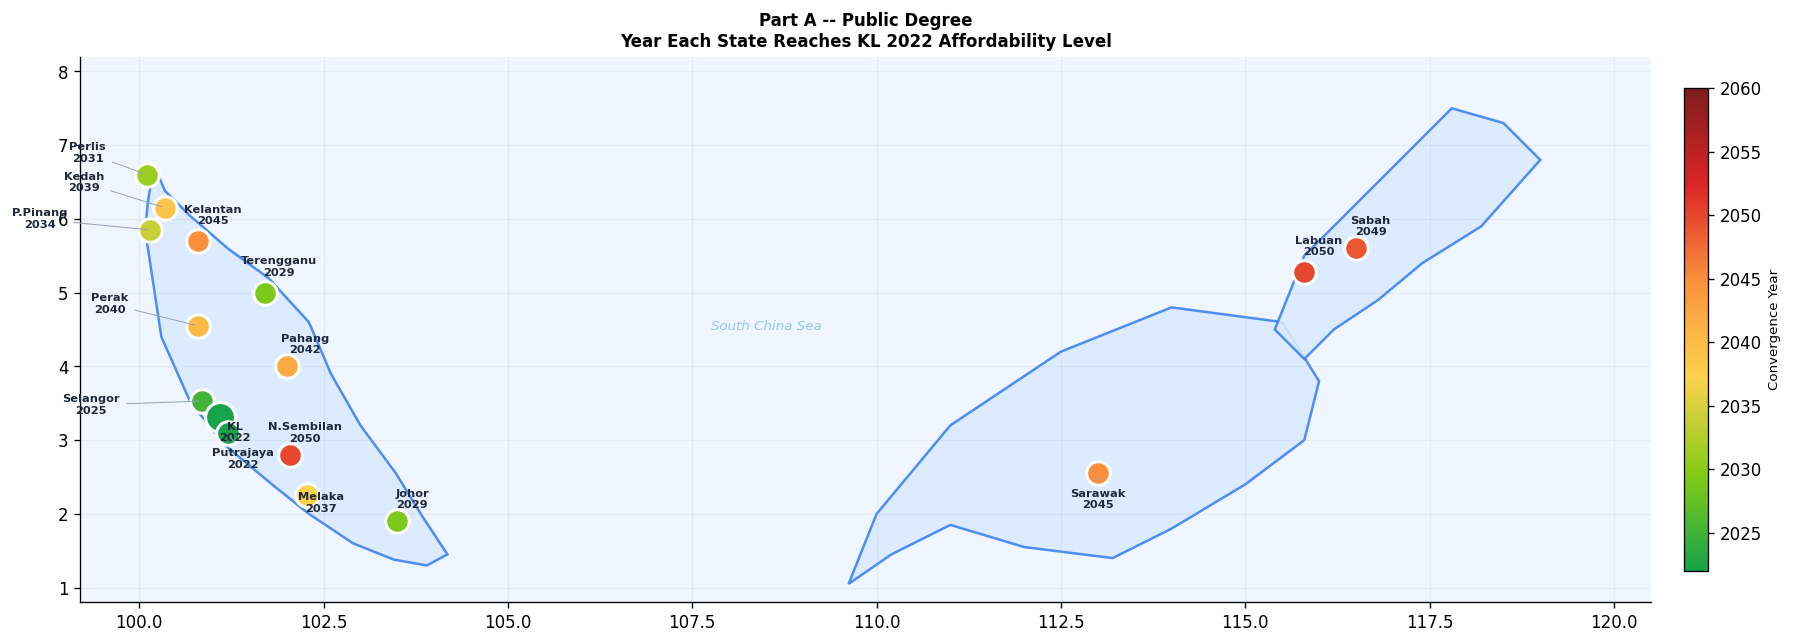

In [79]:
all_conv_public = dict(zip(pub_conv_df['state'], pub_conv_df['conv_year']))
all_conv_public['W.P. Kuala Lumpur'] = 2022
all_conv_public['W.P. Putrajaya']    = 2022

fig, ax = plt.subplots(figsize=(15, 7))
draw_malaysia_map(ax, all_conv_public, 2022, 2060,
                  'Part A -- Public Degree\n'
                  'Year Each State Reaches KL 2022 Affordability Level')
plt.tight_layout()
plt.show()


### A5d -- Interpret the map

We categorise states into three groups based on their convergence year and print the geographic pattern. The map should show a clear divide between the west coast states -- which tend to converge sooner due to higher income growth -- and the east coast and Borneo states, which take longer.

In [80]:
print("MAP INTERPRETATION -- PUBLIC PATHWAY")
print("=" * 55)
print()
print("Green states: converge relatively soon (before ~2035)")
print("Orange states: converge in the medium term (2035-2050)")
print("Red/dark states: take decades or do not converge by 2070")
print()
print("Geographic pattern:")
early  = pub_conv_df[pub_conv_df['conv_year'].apply(lambda x: x is not None and x < 2035)]
late   = pub_conv_df[pub_conv_df['conv_year'].apply(lambda x: x is not None and x >= 2050)]
never  = pub_conv_df[pub_conv_df['conv_year'].isna()]
print(f"  Converge before 2035: {list(early['state'])}")
print(f"  Converge after 2050:  {list(late['state'])}")
print(f"  Do not converge by 2070: {list(never['state'])}")
print()
print("The map makes the postcode penalty immediately visible.")
print("The same degree. The same fee. Very different wait times.")


MAP INTERPRETATION -- PUBLIC PATHWAY

Green states: converge relatively soon (before ~2035)
Orange states: converge in the medium term (2035-2050)
Red/dark states: take decades or do not converge by 2070

Geographic pattern:
  Converge before 2035: ['Perlis', 'Terengganu', 'Pulau Pinang', 'Johor', 'Selangor', 'W.P. Putrajaya']
  Converge after 2050:  ['Negeri Sembilan', 'W.P. Labuan']
  Do not converge by 2070: []

The map makes the postcode penalty immediately visible.
The same degree. The same fee. Very different wait times.


---
# Part B -- Private University Pathway

Part A showed how long it takes each state to reach KL's current affordability
level on the public pathway. Part B asks the same question for families on the
private pathway.

The benchmark is the same: KL's 2022 public affordability level. The question
becomes: when can a family on the private pathway in each state reach the same
level of financial sacrifice that a KL family currently makes for a public degree?

The private fee is 10.7 times larger than the public fee. This means every state
starts from a much heavier burden, and the convergence timeline -- where it exists
at all -- is substantially longer.

Note on fees: the private fee uses APU and Taylor's only, which are premium-tier
institutions. This is an upper bound. The actual average across all private
universities in Malaysia is lower, so the true private burden lies somewhere
between the public and private bars shown.


---
## Step B1 -- How Much Heavier Is the Private Burden in Each State?

Before projecting convergence, we first show what the private pathway costs
relative to the public pathway in each state in 2022. The gap between the two
bars for each state is the cost of being on the private pathway rather than the
public pathway -- visible and quantified for every state in a single chart.

Because the private fee is 10.7 times larger than the public fee, this gap is
substantial in every state. But it is proportionally largest in the poorest states
where income is lowest and the fee represents the greatest number of months of income.


### B1a -- Extract 2022 affordability for both pathways in all states

We pull the 2022 affordability index for both pathways from the dataframe we already computed in Part A. The private index uses the CPI-deflated APU and Taylor's fee, which is the upper bound for private university costs. The ratio column shows how many times heavier the private burden is compared to the public burden -- it is the same for every state because both fees scale by the same CPI deflation factor.

In [81]:
aff_2022_df = aff_df[aff_df['year']==2022].sort_values('aff_private', ascending=True).copy()

print("2022 affordability index -- public vs private:")
print(f"{'State':<25} {'Income/mth':>12} {'Public idx':>12} {'Private idx':>13} {'Ratio':>8}")
print("-" * 75)
for _, row in aff_2022_df.iterrows():
    ratio = row['aff_private'] / row['aff_public']
    print(f"  {row['state']:<23} RM {row['income_median']:>6,}    "
          f"{row['aff_public']:>10.4f}   {row['aff_private']:>11.4f}   {ratio:>6.1f}x")
print()
print("The ratio is the same for all states because both fees scale by the same CPI.")
print("The private pathway costs 10.7x more regardless of state.")


2022 affordability index -- public vs private:
State                       Income/mth   Public idx   Private idx    Ratio
---------------------------------------------------------------------------
  W.P. Kuala Lumpur       RM 10,234        0.0884        0.9857     11.1x
  W.P. Putrajaya          RM 10,056        0.0900        1.0031     11.1x
  Selangor                RM  9,983        0.0906        1.0105     11.1x
  W.P. Labuan             RM  6,904        0.1310        1.4611     11.1x
  Johor                   RM  6,879        0.1315        1.4664     11.1x
  Pulau Pinang            RM  6,502        0.1391        1.5515     11.1x
  Melaka                  RM  6,210        0.1457        1.6244     11.1x
  Terengganu              RM  5,878        0.1539        1.7162     11.1x
  Negeri Sembilan         RM  5,226        0.1731        1.9303     11.1x
  Sarawak                 RM  4,978        0.1817        2.0265     11.1x
  Pahang                  RM  4,753        0.1904        2.122

### B1b -- Plot public vs private burden side by side for all states

Each state has two bars side by side -- blue for public, orange for private. The vertical black dotted line marks KL's 2022 public benchmark. States where even the public bar extends well past this line are far from the benchmark. The private bars will extend roughly 10.7 times further than the public bars for every state.

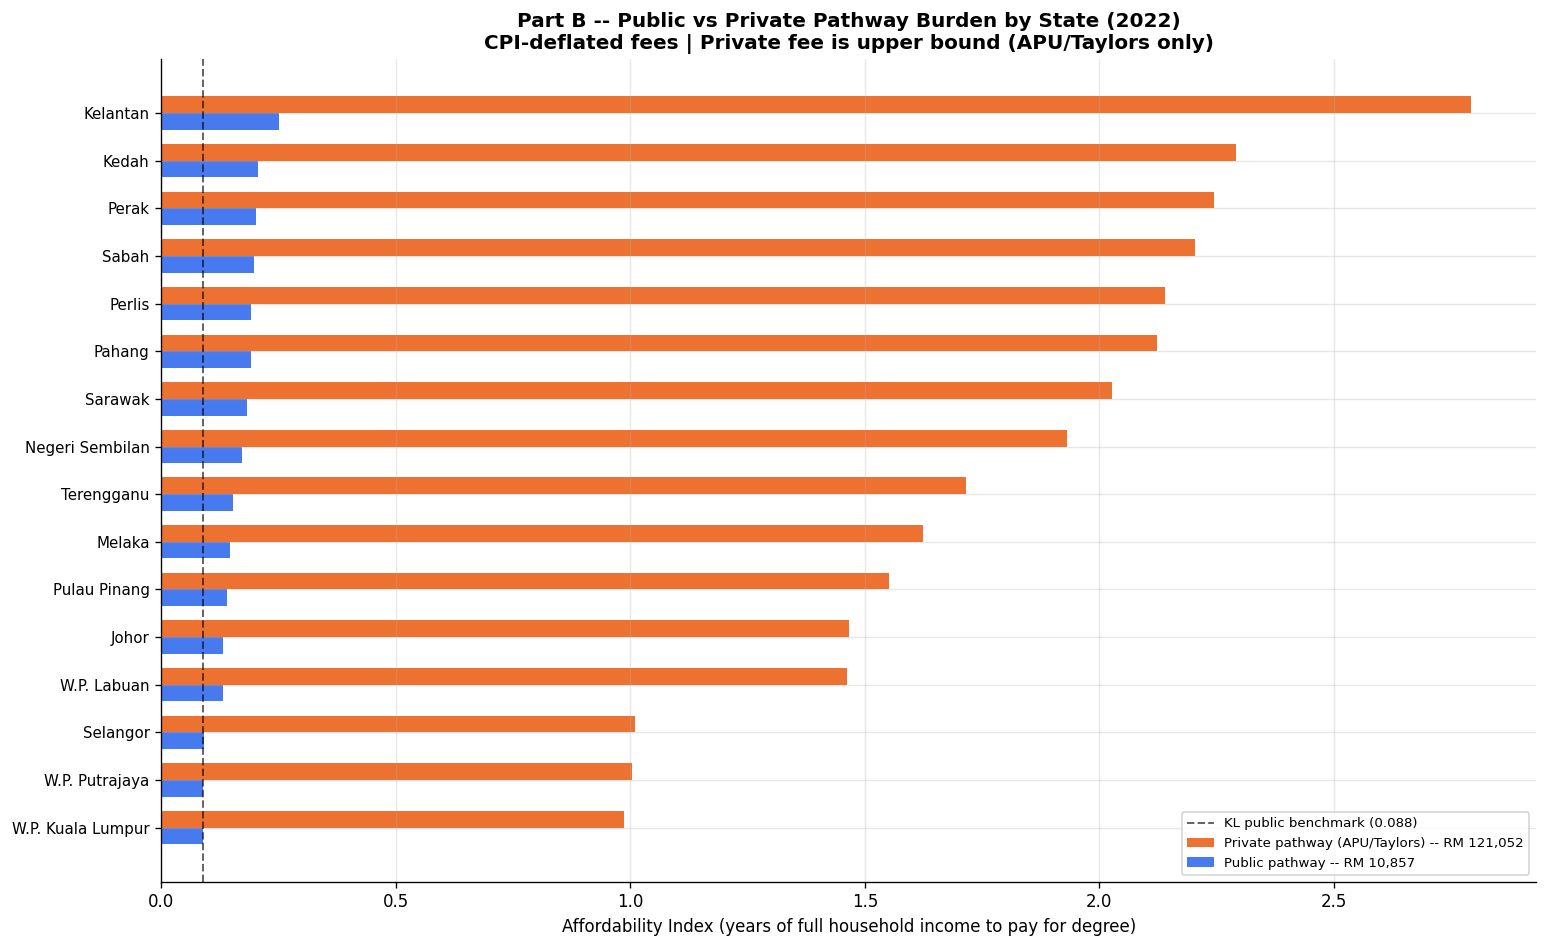

In [82]:
fig, ax = plt.subplots(figsize=(13, 8))
y = np.arange(len(aff_2022_df))
h = 0.35

ax.barh(y + h/2, aff_2022_df['aff_private'], h, color=ORANGE, alpha=0.85,
        label=f'Private pathway (APU/Taylors) -- RM {deflated_fees[2022]["private"]:,.0f}')
ax.barh(y - h/2, aff_2022_df['aff_public'],  h, color=BLUE,   alpha=0.85,
        label=f'Public pathway -- RM {deflated_fees[2022]["public"]:,.0f}')
ax.set_yticks(y)
ax.set_yticklabels(aff_2022_df['state'], fontsize=9)
ax.set_xlabel('Affordability Index (years of full household income to pay for degree)')
ax.set_title('Part B -- Public vs Private Pathway Burden by State (2022)\n'
             'CPI-deflated fees | Private fee is upper bound (APU/Taylors only)',
             fontweight='bold', fontsize=12)
ax.axvline(KL_PUBLIC_2022, color='black', lw=1.2, ls='--', alpha=0.6,
           label=f'KL public benchmark ({KL_PUBLIC_2022:.3f})')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()


### B1c -- Quantify the gap in plain terms

We convert the index into months of household income so the burden is expressed in a unit everyone understands. A value of 20 months means a family would need to save their entire household income for 20 months -- with no other spending -- to pay for the degree. This framing makes the difference between states immediately clear without requiring any understanding of index mechanics.

In [83]:
print("Gap between public and private pathway in each state (2022):")
print()
print(f"{'State':<25} {'Public (months)':>17} {'Private (months)':>18} {'Extra months':>14}")
print("-" * 78)
for _, row in aff_2022_df.sort_values('aff_private', ascending=False).iterrows():
    pub_months  = row['aff_public']  * 12
    priv_months = row['aff_private'] * 12
    extra       = priv_months - pub_months
    print(f"  {row['state']:<23} {pub_months:>15.1f}  {priv_months:>16.1f}  {extra:>12.1f}")
print()
print("'Months' = how many months of full household income to pay for the degree.")


Gap between public and private pathway in each state (2022):

State                       Public (months)   Private (months)   Extra months
------------------------------------------------------------------------------
  Kelantan                            3.0              33.5          30.5
  Kedah                               2.5              27.5          25.0
  Perak                               2.4              26.9          24.5
  Sabah                               2.4              26.4          24.1
  Perlis                              2.3              25.7          23.4
  Pahang                              2.3              25.5          23.2
  Sarawak                             2.2              24.3          22.1
  Negeri Sembilan                     2.1              23.2          21.1
  Terengganu                          1.8              20.6          18.7
  Melaka                              1.7              19.5          17.7
  Pulau Pinang                        1.7

### B1d -- Highlight the states where the private burden is most extreme

We print the three most burdened states in plain language. For each one we show the monthly income, the number of months of full income the private degree costs, and the equivalent number of full years. These three states represent the most severe cases of the postcode penalty on the private pathway.

In [84]:
most_burdened = aff_2022_df.nlargest(3, 'aff_private')
print("Three states where the private pathway is most burdensome:")
print()
for _, row in most_burdened.iterrows():
    months = row['aff_private'] * 12
    print(f"  {row['state']}")
    print(f"    Income: RM {row['income_median']:,}/month")
    print(f"    Private degree costs {months:.1f} months of full household income")
    print(f"    That is {row['aff_private']:.2f} full years of income")
    print()


Three states where the private pathway is most burdensome:

  Kelantan
    Income: RM 3,614/month
    Private degree costs 33.5 months of full household income
    That is 2.79 full years of income

  Kedah
    Income: RM 4,402/month
    Private degree costs 27.5 months of full household income
    That is 2.29 full years of income

  Perak
    Income: RM 4,494/month
    Private degree costs 26.9 months of full household income
    That is 2.24 full years of income



---
## Step B2 -- When Does Each State Reach the Benchmark on the Private Pathway?

We use the same benchmark as Part A: KL's 2022 public affordability level.
The question is: when can a family on the private pathway in each state reach
the same level of financial sacrifice that a KL family currently makes for a
public degree?

We fit a linear regression on each state's private affordability index across
the six HIES years, then project forward to find the convergence year.
For most states this is substantially later than the public pathway convergence
year -- and for many states it does not converge at all within the projection window.


### B2a -- Fit a linear regression on the private affordability index for each state

We repeat the same regression approach used in Part A but applied to the private affordability index. The slope represents how many index points the private burden improves per year. Because the private index starts much higher, even a fast improvement rate may not be enough to reach the KL public benchmark within the projection window.

In [85]:
prv_trends = {}
for state in aff_df['state'].unique():
    df_s  = aff_df[aff_df['state']==state].sort_values('year')
    X     = df_s['year'].values.reshape(-1, 1)
    y_arr = df_s['aff_private'].values
    model = LinearRegression().fit(X, y_arr)
    prv_trends[state] = {'slope': model.coef_[0], 'intercept': model.intercept_,
                         'model': model, 'data': df_s}

print("Linear regression fitted for private pathway -- all states.")
print()
print("Improvement rates (private pathway):")
print(f"{'State':<25} {'Improvement pp/yr':>20}")
print("-" * 48)
for state, t in sorted(prv_trends.items(), key=lambda x: x[1]['slope']):
    print(f"  {state:<23} {-t['slope']*100:>18.3f} pp/yr")


Linear regression fitted for private pathway -- all states.

Improvement rates (private pathway):
State                        Improvement pp/yr
------------------------------------------------
  Perlis                              11.285 pp/yr
  Terengganu                           9.855 pp/yr
  Kelantan                             7.923 pp/yr
  Kedah                                7.546 pp/yr
  Perak                                7.126 pp/yr
  Johor                                6.610 pp/yr
  Pahang                               6.081 pp/yr
  Sarawak                              5.107 pp/yr
  Pulau Pinang                         4.917 pp/yr
  Sabah                                4.826 pp/yr
  Selangor                             4.820 pp/yr
  W.P. Kuala Lumpur                    4.141 pp/yr
  Melaka                               4.136 pp/yr
  Negeri Sembilan                      3.530 pp/yr
  W.P. Putrajaya                       3.380 pp/yr
  W.P. Labuan                          1.

### B2b -- Find the private pathway convergence year for each state

We project each state's private regression line forward to 2070 and find the first year it crosses below KL's 2022 public level. Many states will not cross before 2070. This is not a data error -- it means that even under current income growth trends, a family on the private pathway in that state will not reach KL's current public burden level within the next five decades.

In [89]:
prv_conv = []
for state, t in prv_trends.items():
    if state == 'W.P. Kuala Lumpur':
        continue
    proj    = t['model'].predict(PROJ_YEARS.reshape(-1, 1))
    crossed = PROJ_YEARS[proj <= KL_PUBLIC_2022]
    conv_yr = int(crossed[0]) if len(crossed) > 0 else None
    aff_2022_val = aff_df[(aff_df['state']==state) & (aff_df['year']==2022)]['aff_private'].values[0]
    prv_conv.append({'state': state, 'aff_2022': aff_2022_val, 'conv_year': conv_yr})

prv_conv_df = pd.DataFrame(prv_conv).sort_values('aff_2022', ascending=False)
prv_conv_df

print("Private pathway convergence years (target = KL public 2022 level):")
print(f"{'State':<25} {'Private idx 2022':>18} {'Converges':>12}")
print("-" * 58)
for _, row in prv_conv_df.iterrows():
    cy = str(int(row['conv_year'])) if pd.notna(row['conv_year']) else '>2070'
    print(f"  {row['state']:<23} {row['aff_2022']:>18.4f} {cy:>12}")


Private pathway convergence years (target = KL public 2022 level):
State                       Private idx 2022    Converges
----------------------------------------------------------
  Kelantan                            2.7913         2057
  Kedah                               2.2916         2051
  Perak                               2.2447         2053
  Sabah                               2.2040         2067
  Perlis                              2.1404         2039
  Pahang                              2.1224         2056
  Sarawak                             2.0265         2063
  Negeri Sembilan                     1.9303        >2070
  Terengganu                          1.7162         2038
  Melaka                              1.6244         2059
  Pulau Pinang                        1.5515         2052
  Johor                               1.4664         2043
  W.P. Labuan                         1.4611        >2070
  Selangor                            1.0105         2043
  W.

### B2c -- Compare public vs private convergence year for each state

We merge the public and private convergence years into a single table and compute the extra wait time the private pathway imposes. The extra wait column is the direct answer to how many additional years a family faces simply because they are on the private pathway rather than the public one.

In [90]:
comparison = pub_conv_df[['state','conv_year']].rename(columns={'conv_year':'pub_conv'})
comparison = comparison.merge(
    prv_conv_df[['state','conv_year']].rename(columns={'conv_year':'prv_conv'}),
    on='state', how='outer'
)

print("Public vs private convergence year comparison:")
print(f"{'State':<25} {'Public':>10} {'Private':>12} {'Extra wait':>12}")
print("-" * 62)
for _, row in comparison.sort_values('pub_conv').iterrows():
    pub_str = str(int(row['pub_conv'])) if pd.notna(row['pub_conv']) and row['pub_conv'] else '>2070'
    prv_str = str(int(row['prv_conv'])) if pd.notna(row['prv_conv']) and row['prv_conv'] else '>2070'
    if pd.notna(row['pub_conv']) and pd.notna(row['prv_conv']) and row['pub_conv'] and row['prv_conv']:
        extra = f"+{int(row['prv_conv']) - int(row['pub_conv'])} yrs"
    else:
        extra = 'n/a'
    print(f"  {row['state']:<23} {pub_str:>10} {prv_str:>12} {extra:>12}")


Public vs private convergence year comparison:
State                         Public      Private   Extra wait
--------------------------------------------------------------
  W.P. Putrajaya                2022         2048      +26 yrs
  Selangor                      2025         2043      +18 yrs
  Terengganu                    2029         2038       +9 yrs
  Johor                         2029         2043      +14 yrs
  Perlis                        2031         2039       +8 yrs
  Pulau Pinang                  2034         2052      +18 yrs
  Melaka                        2037         2059      +22 yrs
  Kedah                         2039         2051      +12 yrs
  Perak                         2040         2053      +13 yrs
  Pahang                        2042         2056      +14 yrs
  Kelantan                      2045         2057      +12 yrs
  Sarawak                       2045         2063      +18 yrs
  Sabah                         2049         2067      +18 yrs
  Negeri

### B2d -- Plot the private convergence projection and gap chart

Same layout as A3c but for the private pathway. The left panel shows projection lines crossing the KL public benchmark. The right panel shows each state's private affordability index in 2022 as a bar with the convergence year labelled. States where no convergence year is annotated do not reach the benchmark before 2070.

ValueError: cannot convert float NaN to integer

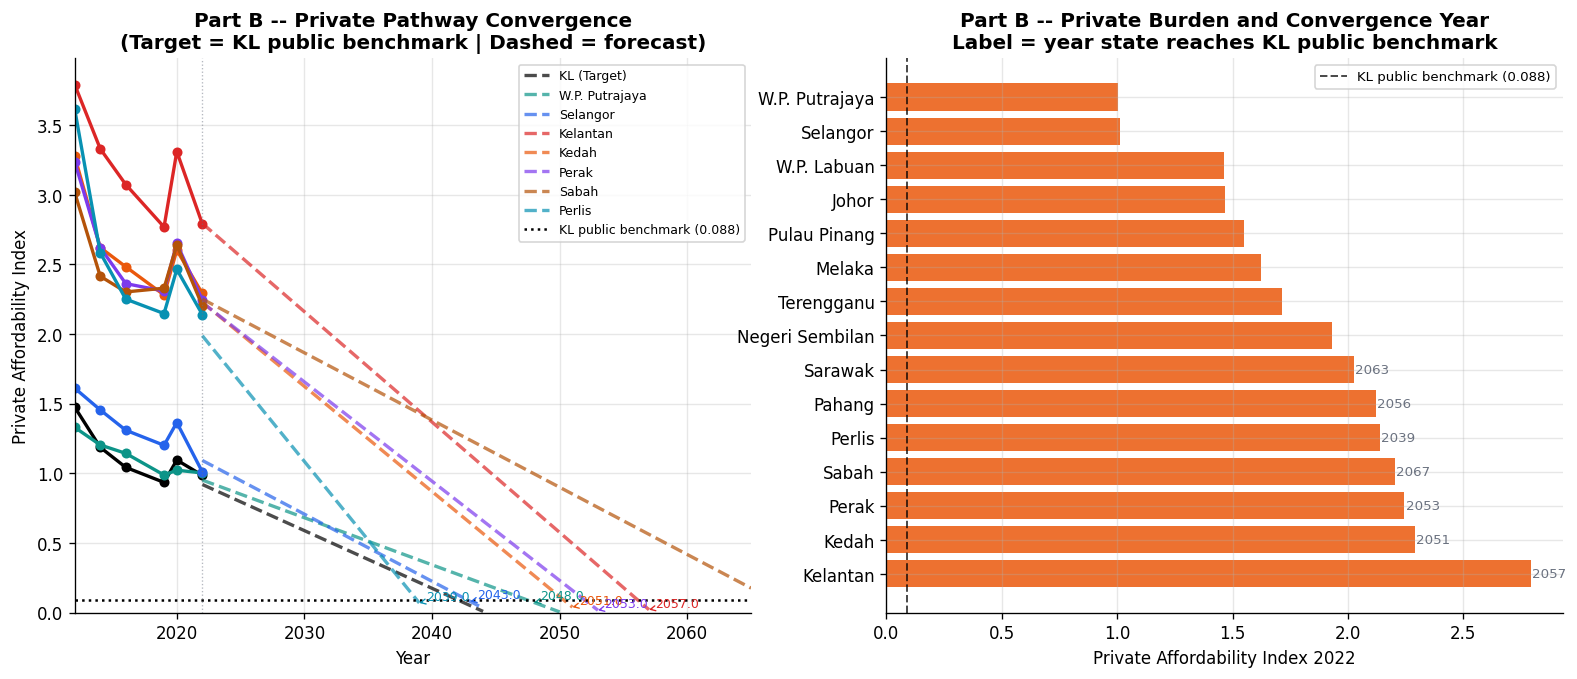

In [91]:
worst_5p = prv_conv_df.nlargest(5,  'aff_2022')['state'].tolist()
best_2p  = prv_conv_df.nsmallest(2, 'aff_2022')['state'].tolist()
focus_p  = ['W.P. Kuala Lumpur'] + best_2p + worst_5p

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, state in enumerate(focus_p):
    t      = prv_trends[state]
    hist   = aff_df[aff_df['state']==state].sort_values('year')
    proj   = t['model'].predict(PROJ_YEARS.reshape(-1, 1))
    proj_c = np.maximum(proj, 0)
    color  = palette[i % len(palette)]
    lbl    = 'KL (Target)' if state == 'W.P. Kuala Lumpur' else state
    mask   = (PROJ_YEARS <= 2065) & (proj >= 0)

    axes[0].plot(hist['year'], hist['aff_private'],
                 color=color, lw=2, marker='o', markersize=5)
    axes[0].plot(PROJ_YEARS[mask], proj_c[mask],
                 color=color, lw=2, ls='--', alpha=0.7, label=lbl)

    row_p = prv_conv_df[prv_conv_df['state']==state]
    if not row_p.empty and row_p['conv_year'].values[0]:
        cy = row_p['conv_year'].values[0]
        if cy <= 2065:
            cv = max(t['model'].predict([[cy]])[0], 0)
            axes[0].annotate(f'{cy}', xy=(cy, cv), xytext=(cy+0.5, cv+0.02),
                fontsize=7.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

axes[0].axhline(KL_PUBLIC_2022, color='black', lw=1.5, ls=':',
                label=f'KL public benchmark ({KL_PUBLIC_2022:.3f})')
axes[0].axvline(2022, color=GRAY, lw=0.8, ls=':', alpha=0.5)
axes[0].set_ylim(bottom=0)
axes[0].set_xlim(2012, 2065)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Private Affordability Index')
axes[0].set_title('Part B -- Private Pathway Convergence\n'
                  '(Target = KL public benchmark | Dashed = forecast)',
                  fontweight='bold')
axes[0].legend(fontsize=7.5)

gap_p = prv_conv_df.sort_values('aff_2022', ascending=False)
bars  = axes[1].barh(gap_p['state'], gap_p['aff_2022'], color=ORANGE, alpha=0.85)
axes[1].axvline(KL_PUBLIC_2022, color='black', lw=1.2, ls='--', alpha=0.7,
                label=f'KL public benchmark ({KL_PUBLIC_2022:.3f})')
axes[1].set_xlabel('Private Affordability Index 2022')
axes[1].set_title('Part B -- Private Burden and Convergence Year\n'
                  'Label = year state reaches KL public benchmark',
                  fontweight='bold')
axes[1].legend(fontsize=8)
for bar, (_, row) in zip(bars, gap_p.iterrows()):
    lbl = str(int(row['conv_year'])) if row['conv_year'] else '>2070'
    axes[1].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 lbl, va='center', fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()


---
## Step B3 -- Side by Side Map: Public vs Private Convergence Year

We place the public convergence map and the private convergence map next to each
other using the same colour scale. The private map will be significantly darker
across every state.

Placing them side by side lets the colour difference speak for itself. The reader
does not need to read any numbers to understand that the private pathway takes
substantially longer to reach the same benchmark in every state across the country.


### B3a -- Build the private convergence year dictionary

We build the same kind of dictionary used for the public map but populated with private convergence years. We print a side by side comparison of public and private years for every state so the full picture is visible before we draw the map.

In [94]:
all_conv_private = dict(zip(prv_conv_df['state'], prv_conv_df['conv_year']))
all_conv_private['W.P. Kuala Lumpur'] = 2022
all_conv_private['W.P. Putrajaya']    = 2022

print("Private convergence year dictionary built.")
print()
print("Comparison -- public vs private convergence year:")
for state in sorted(all_conv_public.keys()):
    pub_yr = all_conv_public.get(state)
    prv_yr = all_conv_private.get(state)
    pub_str = str(int(pub_yr)) if pd.notna(pub_yr) else '>2070'
    prv_str = str(int(prv_yr)) if pd.notna(prv_yr) else '>2070'
    print(f"  {state:<25} Public: {pub_str:<8} Private: {prv_str}")


Private convergence year dictionary built.

Comparison -- public vs private convergence year:
  Johor                     Public: 2029     Private: 2043
  Kedah                     Public: 2039     Private: 2051
  Kelantan                  Public: 2045     Private: 2057
  Melaka                    Public: 2037     Private: 2059
  Negeri Sembilan           Public: 2050     Private: >2070
  Pahang                    Public: 2042     Private: 2056
  Perak                     Public: 2040     Private: 2053
  Perlis                    Public: 2031     Private: 2039
  Pulau Pinang              Public: 2034     Private: 2052
  Sabah                     Public: 2049     Private: 2067
  Sarawak                   Public: 2045     Private: 2063
  Selangor                  Public: 2025     Private: 2043
  Terengganu                Public: 2029     Private: 2038
  W.P. Kuala Lumpur         Public: 2022     Private: 2022
  W.P. Labuan               Public: 2050     Private: >2070
  W.P. Putrajaya   

### B3b -- Plot both maps side by side

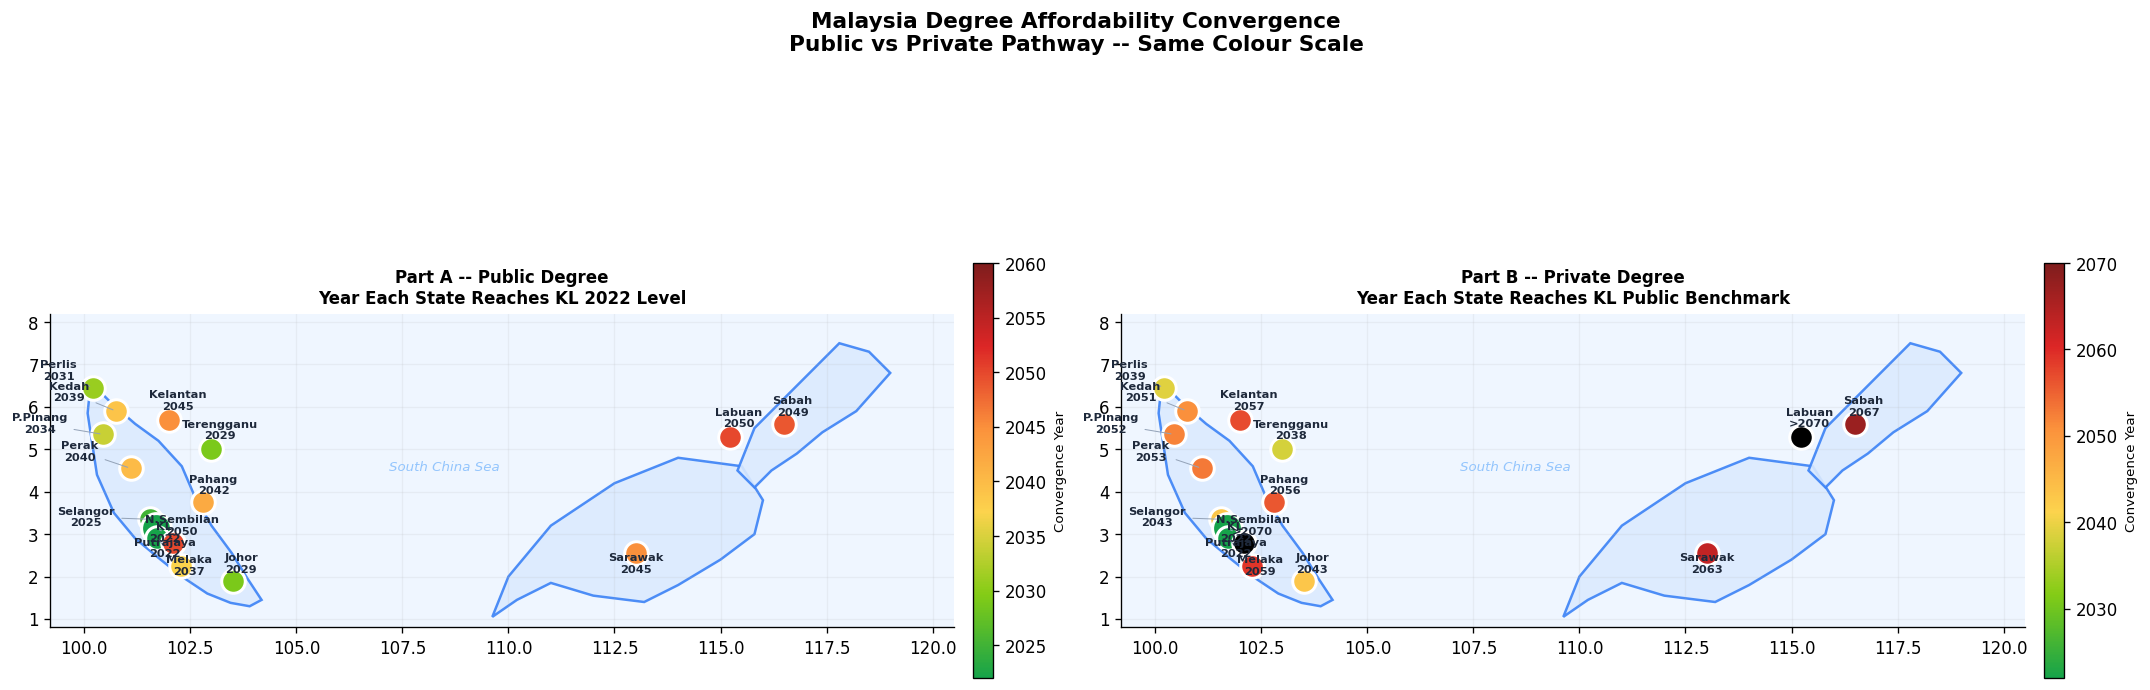

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

draw_malaysia_map(axes[0], all_conv_public,  2022, 2060,
                  'Part A -- Public Degree\nYear Each State Reaches KL 2022 Level')
draw_malaysia_map(axes[1], all_conv_private, 2022, 2070,
                  'Part B -- Private Degree\nYear Each State Reaches KL Public Benchmark')

plt.suptitle('Malaysia Degree Affordability Convergence\n'
             'Public vs Private Pathway -- Same Colour Scale',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### B3c -- Summarise the side by side comparison

We compute the average convergence year for each pathway and the average extra wait the private pathway imposes. We also count how many states never converge before 2070 on each pathway. The difference in these two counts is the clearest single statement of how much worse the private pathway situation is compared to the public one.

In [ ]:
print("SIDE BY SIDE SUMMARY")
print("=" * 60)
print()
print("The two maps use the same colour scale.")
print("Any state that is darker on the right map takes longer on")
print("the private pathway to reach the same benchmark.")
print()

pub_avg_conv  = np.mean([v for v in all_conv_public.values()
                          if v and v < 9000 and v > 2022])
prv_avg_conv  = np.mean([v for v in all_conv_private.values()
                          if v and v < 9000 and v > 2022])

print(f"Average convergence year -- public pathway:  {pub_avg_conv:.0f}")
print(f"Average convergence year -- private pathway: {prv_avg_conv:.0f}")
print(f"Average extra wait on private pathway:       {prv_avg_conv - pub_avg_conv:.0f} years")
print()
pub_never  = sum(1 for v in all_conv_public.values()  if not v)
prv_never  = sum(1 for v in all_conv_private.values() if not v)
print(f"States that never converge before 2070:")
print(f"  Public pathway:  {pub_never} states")
print(f"  Private pathway: {prv_never} states")

os.makedirs('../data/analysis', exist_ok=True)
pub_conv_df.to_csv('../data/analysis/convergence_public.csv',  index=False)
prv_conv_df.to_csv('../data/analysis/convergence_private.csv', index=False)
print()
print("Saved -> ../data/analysis/convergence_public.csv")
print("Saved -> ../data/analysis/convergence_private.csv")


SIDE BY SIDE SUMMARY

The two maps use the same colour scale.
Any state that is darker on the right map takes longer on
the private pathway to reach the same benchmark.

Average convergence year -- public pathway:  2039
Average convergence year -- private pathway: 2052
Average extra wait on private pathway:       13 years

States that never converge before 2070:
  Public pathway:  0 states
  Private pathway: 0 states

Saved -> ../data/analysis/convergence_public.csv
Saved -> ../data/analysis/convergence_private.csv


### B3d -- Final interpretation

We close the notebook with a plain language statement of the core finding. The convergence year is not just a number -- it is the wait time for fairness. We translate the worst-case convergence years into human terms: how many years from today, and what that means for a student enrolling right now.

In [ ]:
print("=" * 65)
print("FINAL INTERPRETATION")
print("=" * 65)
print()
print("YOUR POSTCODE SHOULD NOT DETERMINE YOUR PRICE TAG FOR A BETTER FUTURE.")
print()
print("Malaysia charges every student the same fee for the same degree.")
print("But the same fee means very different levels of sacrifice depending")
print("on where a family lives and which university pathway they are on.")
print()
print("The convergence year is the wait time for fairness.")
print("It answers: how long before a family in this state faces the same")
print("financial burden that a KL family faces today?")
print()
print("Key findings:")
print()
worst_pub = pub_conv_df.loc[pub_conv_df['conv_year'].isna() |
                             pub_conv_df['conv_year'].apply(lambda x: x is None or x > 2050)]
for _, row in pub_conv_df.nlargest(3, 'gap').iterrows():
    cy = str(int(row['conv_year'])) if row['conv_year'] else '>2070'
    wait = (int(row['conv_year']) - 2022) if row['conv_year'] else '>48'
    print(f"  {row['state']}: public pathway convergence {cy} -- {wait} years from now")
print()
print("If the convergence year is 30 years away, it means a student enrolling")
print("today will graduate, work their entire career, and approach retirement")
print("before their home state reaches the affordability level that KL has today.")
print()
print("This is not a gap that the economy will fix by itself.")
print("It is a structural inequality that requires deliberate policy to address.")


FINAL INTERPRETATION

YOUR POSTCODE SHOULD NOT DETERMINE YOUR PRICE TAG FOR A BETTER FUTURE.

Malaysia charges every student the same fee for the same degree.
But the same fee means very different levels of sacrifice depending
on where a family lives and which university pathway they are on.

The convergence year is the wait time for fairness.
It answers: how long before a family in this state faces the same
financial burden that a KL family faces today?

Key findings:

  Kelantan: public pathway convergence 2045 -- 23 years from now
  Kedah: public pathway convergence 2039 -- 17 years from now
  Perak: public pathway convergence 2040 -- 18 years from now

If the convergence year is 30 years away, it means a student enrolling
today will graduate, work their entire career, and approach retirement
before their home state reaches the affordability level that KL has today.

This is not a gap that the economy will fix by itself.
It is a structural inequality that requires deliberate policy 